In [4]:
from transformers import SegformerImageProcessor, AutoModelForSemanticSegmentation
from PIL import Image
import requests
import matplotlib.pyplot as plt
import torch.nn as nn
import numpy as np
import torch

processor = SegformerImageProcessor.from_pretrained("mattmdjaga/segformer_b2_clothes")
model = AutoModelForSemanticSegmentation.from_pretrained("mattmdjaga/segformer_b2_clothes")

image_path = "products/109223434/image_3.jpg"

image = Image.open(image_path)
inputs = processor(images=image, return_tensors="pt")

outputs = model(**inputs)
logits = outputs.logits.cpu()

upsampled_logits = nn.functional.interpolate(
    logits,
    size=image.size[::-1],
    mode="bilinear",
    align_corners=False,
)

pred_seg = upsampled_logits.argmax(dim=1)[0]

/mnt/500gb/Documents/Documents/image_segmentation/.venv/lib/python3.13/site-packages/transformers/image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


Detected classes in the image:
--------------------------------------------------
Upper-clothes       :  2172246 pixels (45.89%)
Background          :  1881833 pixels (39.75%)
Hair                :   276280 pixels ( 5.84%)
Face                :   241654 pixels ( 5.10%)
Left-arm            :    96933 pixels ( 2.05%)
Right-arm           :    65162 pixels ( 1.38%)


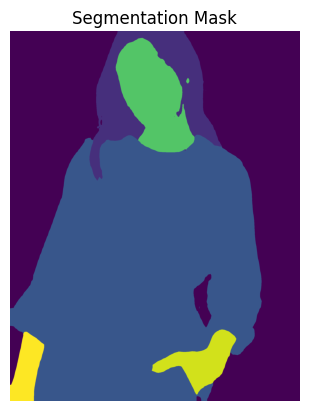

In [5]:
# Extract unique class IDs from the segmentation mask
unique_classes = torch.unique(pred_seg).numpy()

# Get class labels from model config if available, otherwise use default
if hasattr(model.config, 'id2label') and model.config.id2label:
    id2label = model.config.id2label
    class_labels = {int(k): v for k, v in id2label.items()}
else:
    # Default class labels for segformer_b2_clothes
    class_labels = {
        0: "Background", 1: "Hat", 2: "Hair", 3: "Sunglasses", 4: "Upper-clothes",
        5: "Skirt", 6: "Pants", 7: "Dress", 8: "Belt", 9: "Left-shoe",
        10: "Right-shoe", 11: "Face", 12: "Left-leg", 13: "Right-leg",
        14: "Left-arm", 15: "Right-arm", 16: "Bag", 17: "Scarf"
    }

# Extract detected classes
detected_classes = {}
for class_id in unique_classes:
    class_id_int = int(class_id)
    if class_id_int in class_labels:
        pixel_count = (pred_seg == class_id).sum().item()
        detected_classes[class_labels[class_id_int]] = pixel_count

print("Detected classes in the image:")
print("-" * 50)
for class_name, pixel_count in sorted(detected_classes.items(), key=lambda x: x[1], reverse=True):
    percentage = (pixel_count / pred_seg.numel()) * 100
    print(f"{class_name:20s}: {pixel_count:8d} pixels ({percentage:5.2f}%)")

plt.imshow(pred_seg)
plt.title("Segmentation Mask")
plt.axis('off')
plt.show()

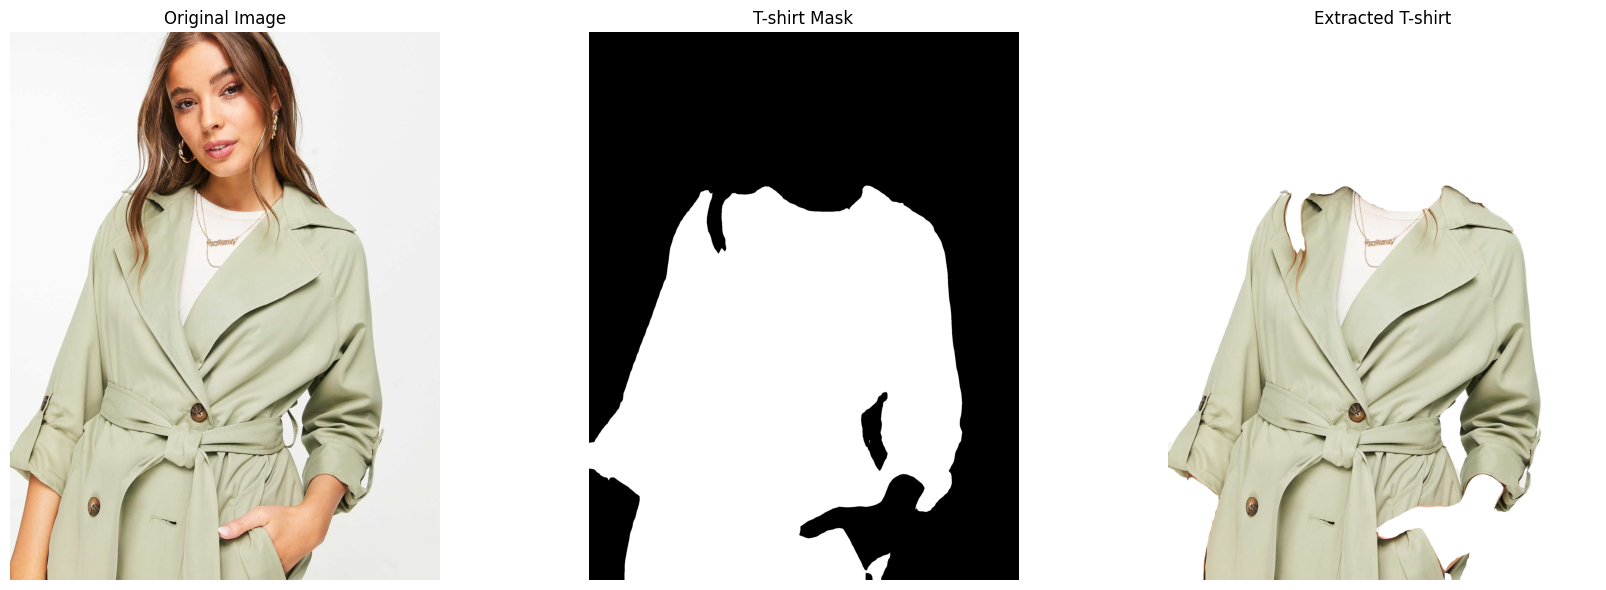

Saved: tshirt_extracted_white_bg.png
Saved: tshirt_extracted_transparent.png


In [6]:
# Find the class ID for "Upper-clothes"
upper_clothes_id = None
for class_id, class_name in class_labels.items():
    if class_name == "Upper-clothes":
        upper_clothes_id = class_id
        break

if upper_clothes_id is not None:
    # Create a binary mask for Upper-clothes
    tshirt_mask = (pred_seg == upper_clothes_id).numpy()
    
    # Convert original image to numpy array
    image_array = np.array(image)
    
    # Apply mask to extract t-shirt (set non-tshirt pixels to white/transparent)
    # Option 1: Set background to white
    tshirt_extracted = image_array.copy()
    tshirt_extracted[~tshirt_mask] = [255, 255, 255]  # White background
    
    # Option 2: Set background to transparent (for PNG with alpha channel)
    # Create RGBA image
    tshirt_rgba = np.zeros((image_array.shape[0], image_array.shape[1], 4), dtype=np.uint8)
    tshirt_rgba[:, :, :3] = image_array
    tshirt_rgba[:, :, 3] = 255  # Full opacity
    tshirt_rgba[~tshirt_mask, 3] = 0  # Transparent background
    
    # Visualize the results
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Original image
    axes[0].imshow(image_array)
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    # T-shirt mask
    axes[1].imshow(tshirt_mask, cmap='gray')
    axes[1].set_title('T-shirt Mask')
    axes[1].axis('off')
    
    # Extracted t-shirt (white background)
    axes[2].imshow(tshirt_extracted)
    axes[2].set_title('Extracted T-shirt')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Save the extracted t-shirt
    # Option 1: Save with white background
    tshirt_image_white = Image.fromarray(tshirt_extracted)
    tshirt_image_white.save('tshirt_extracted_white_bg.png')
    print("Saved: tshirt_extracted_white_bg.png")
    
    # Option 2: Save with transparent background
    tshirt_image_transparent = Image.fromarray(tshirt_rgba, 'RGBA')
    tshirt_image_transparent.save('tshirt_extracted_transparent.png')
    print("Saved: tshirt_extracted_transparent.png")
    
else:
    print("Upper-clothes class not found in the model!")
